<a href="https://colab.research.google.com/github/id-05/MedtechTools_console/blob/master/segmentation_acdc.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Установка библиотек

In [ ]:
!pip install -q nibabel monai torchmetrics

Импорт библиотек

In [ ]:
import os
import glob
import random
import numpy as np
import matplotlib.pyplot as plt

import nibabel as nib

from pathlib import Path
from tqdm.auto import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split

from monai.networks.nets import AttentionUnet

In [ ]:
from monai.transforms import (
    Resize,
    Compose
)

##ACDC — Automated Cardiac Diagnosis Challenge

ACDC (Automated Cardiac Diagnosis Challenge) — датасет кардиальных МРТ-исследований, предназначенный для разработки и оценки методов автоматического анализа изображений сердца.

В датасете представлены cine-МРТ сердца, полученные в течение сердечного цикла. Для изображений доступны экспертные пиксельные маски трёх основных структур:

RV — правый желудочек;
MYO — миокард;
LV — левый желудочек.

В данной работе ACDC используется для задачи сегментации сердца с помощью нейронной сети U-Net. После получения сегментации маски можно использовать для количественного анализа: расчёта площадей и объёмов сердечных структур.

Скачаем данные

In [51]:
import gdown

url = "https://drive.google.com/drive/folders/18STEw4jqcQoPtpeHlS9UpxK7K9aLcKgQ?usp=sharing"
gdown.download_folder(url, quiet=True, use_cookies=False)

['/content/MRI_school_zip/MRI_school_zip.zip']

In [55]:
!unzip /content/MRI_school_zip/MRI_school_zip.zip  -d /content/MRI_school_zip/

Archive:  /content/MRI_school_zip/MRI_school_zip.zip
replace /content/MRI_school_zip/MRI_school_zip/test_images/patient_0040_0000.nii.gz? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

Переключаемся на GPU

In [56]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: Tesla T4


## Знакомство с данными и подготовка

Обозначаем пути к папкам

In [57]:
DATA_ROOT = Path("/content/MRI_school_zip/MRI_school_zip")

In [58]:
TRAIN_IMG_DIR = DATA_ROOT / "train_images"
TRAIN_MASK_DIR = DATA_ROOT / "train_labels"

TEST_IMG_DIR = DATA_ROOT / "test_images"
TEST_MASK_DIR = DATA_ROOT / "test_labels"

print("Train images:", TRAIN_IMG_DIR)
print("Train masks:", TRAIN_MASK_DIR)
print("Test images:", TEST_IMG_DIR)
print("Test masks:", TEST_MASK_DIR)

Train images: /content/MRI_school_zip/MRI_school_zip/train_images
Train masks: /content/MRI_school_zip/MRI_school_zip/train_labels
Test images: /content/MRI_school_zip/MRI_school_zip/test_images
Test masks: /content/MRI_school_zip/MRI_school_zip/test_labels


Посмотрим, что лежит в папках

In [59]:
train_images = sorted(
    list(TRAIN_IMG_DIR.glob("*.nii")) +
    list(TRAIN_IMG_DIR.glob("*.nii.gz"))
)

train_masks = sorted(
    list(TRAIN_MASK_DIR.glob("*.nii")) +
    list(TRAIN_MASK_DIR.glob("*.nii.gz"))
)

test_images = sorted(
    list(TEST_IMG_DIR.glob("*.nii")) +
    list(TEST_IMG_DIR.glob("*.nii.gz"))
)

test_masks = sorted(
    list(TEST_MASK_DIR.glob("*.nii")) +
    list(TEST_MASK_DIR.glob("*.nii.gz"))
)

print("Train images:", len(train_images))
print("Train masks:", len(train_masks))
print("Test images:", len(test_images))
print("Test masks:", len(test_masks))

print("\nExample image:")
print(train_images[0])

print("\nExample mask:")
print(train_masks[0])

Train images: 224
Train masks: 224
Test images: 60
Test masks: 60

Example image:
/content/MRI_school_zip/MRI_school_zip/train_images/cardiac_0000_0000.nii.gz

Example mask:
/content/MRI_school_zip/MRI_school_zip/train_labels/cardiac_0000.nii.gz


In [60]:
# Загружаем Nifti файл и преобразуем его в матрицу

def load_nifti(path):
    nii = nib.load(str(path))
    data = nii.get_fdata()

    return data

Посмотрим размерности и количество классов в масках

In [61]:
image = load_nifti(train_images[0])
mask = load_nifti(train_masks[0])

print("Image shape:", image.shape)
print("Mask shape:", mask.shape)

print("Image dtype:", image.dtype)
print("Mask dtype:", mask.dtype)

print("Image min/max:", image.min(), image.max())
print("Mask values:", np.unique(mask))

Image shape: (216, 256, 10)
Mask shape: (216, 256, 10)
Image dtype: float64
Mask dtype: float64
Image min/max: 0.0 658.0
Mask values: [0. 1. 2. 3.]


0 — background
1 — right ventricle
2 — myocardium
3 — left ventricle

In [63]:
print("Classes:", np.unique(mask).astype(int))

Classes: [0 1 2 3]


Посмотрим на примеры

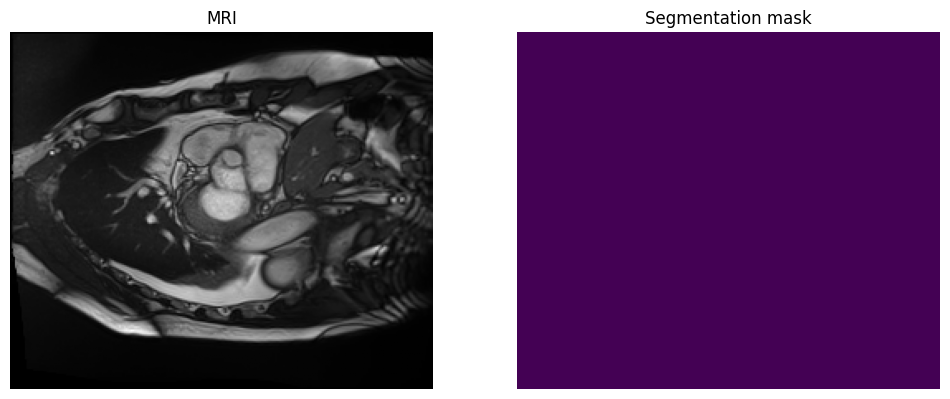

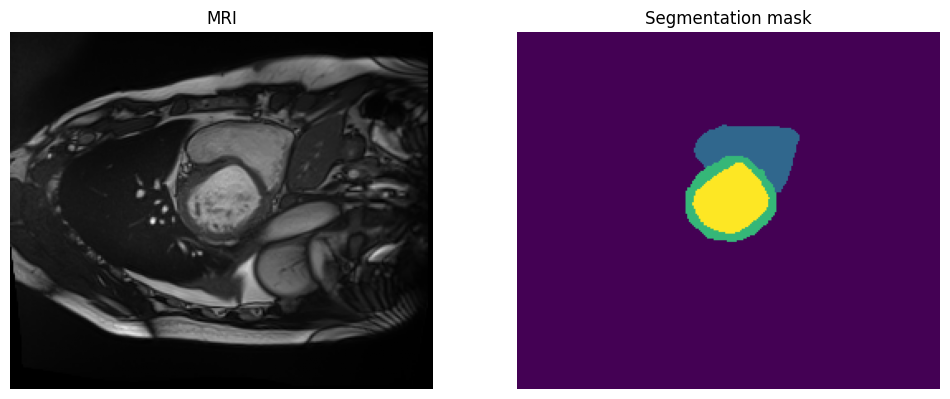

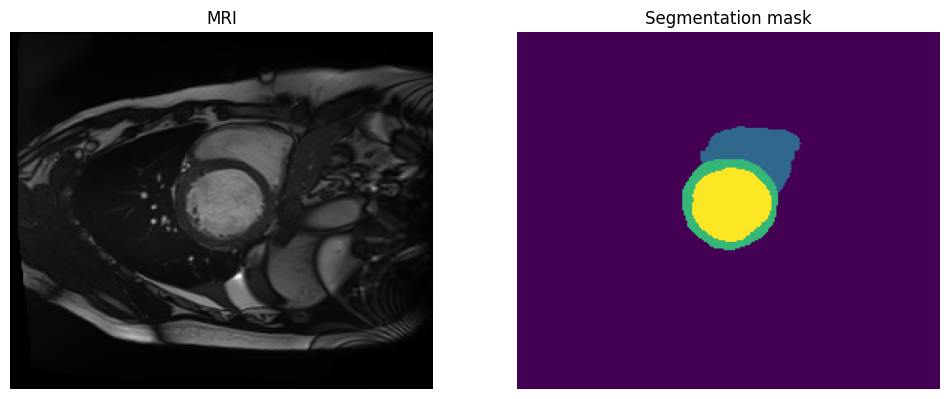

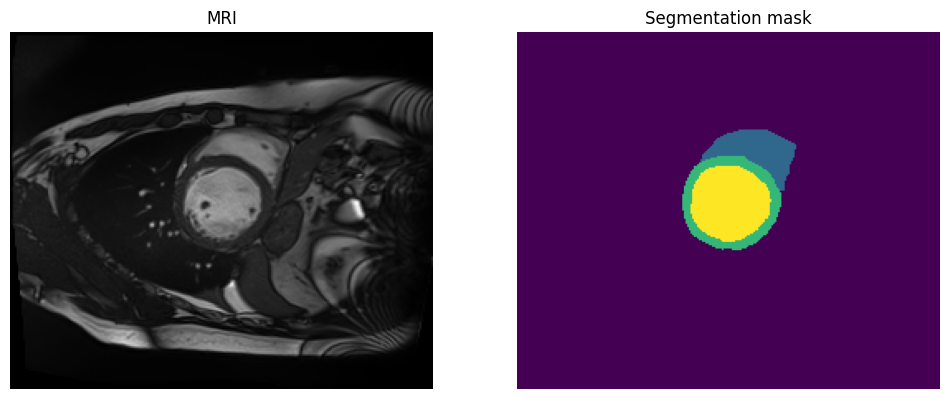

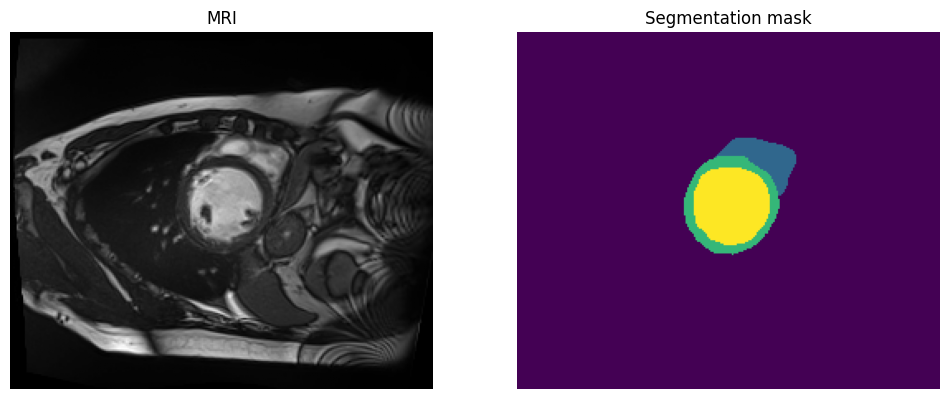

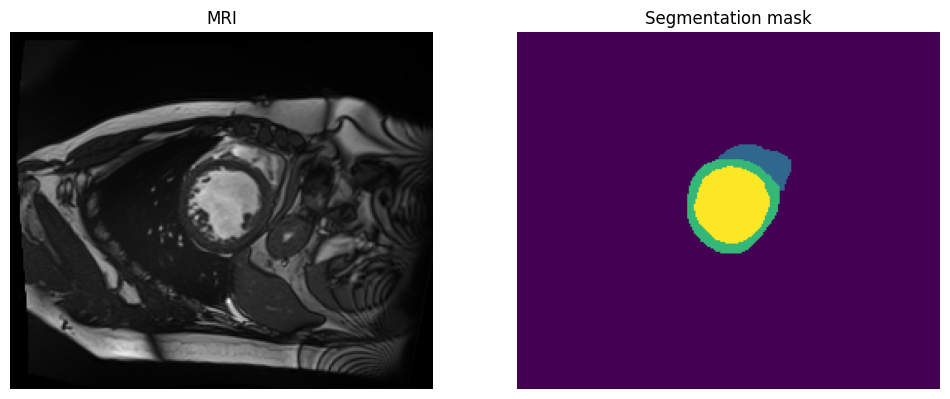

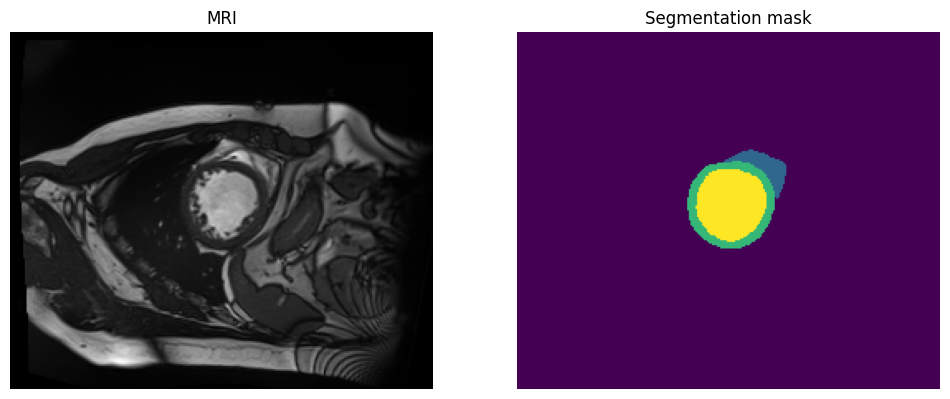

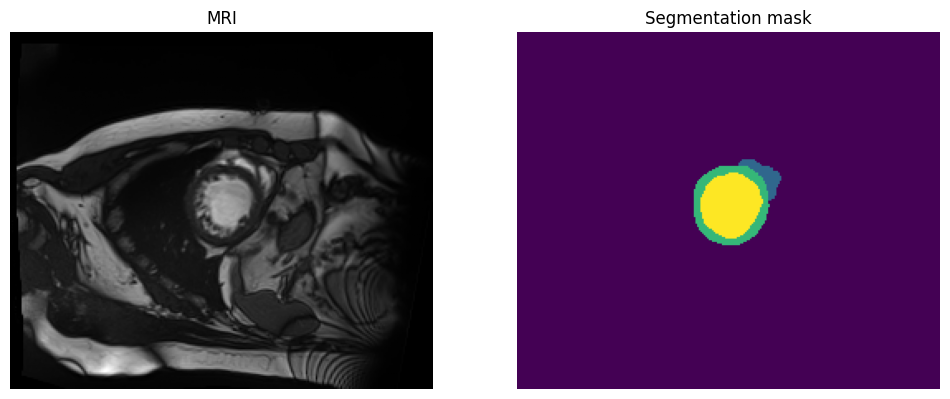

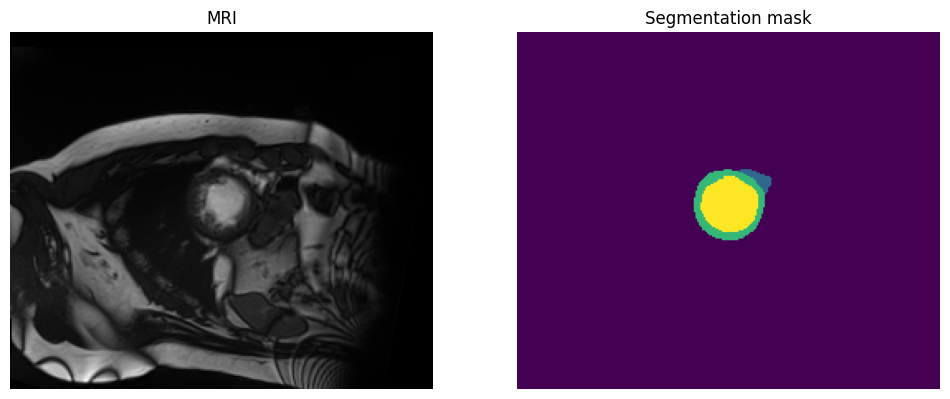

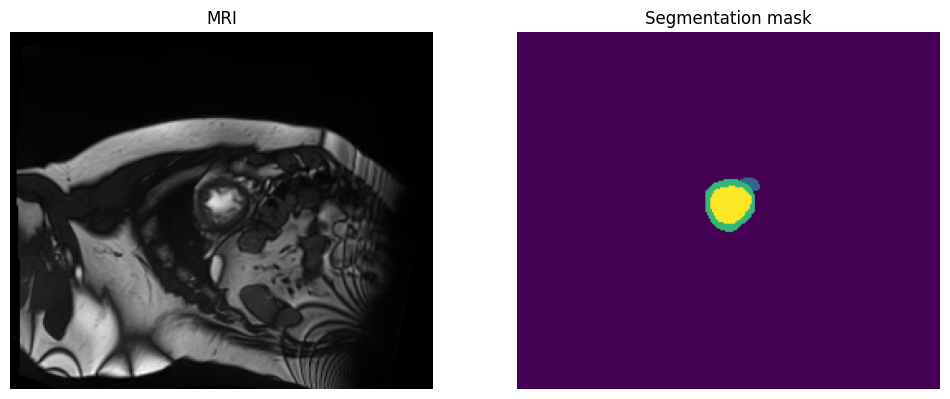

In [62]:
slice_id = image.shape[2] // 2

for k in range(10):
  fig, axes = plt.subplots(1, 2, figsize=(12, 5))

  axes[0].imshow(image[:, :, k], cmap="gray")
  axes[0].set_title("MRI")
  axes[0].axis("off")

  axes[1].imshow(mask[:, :, k])
  axes[1].set_title("Segmentation mask")
  axes[1].axis("off")

  plt.show()

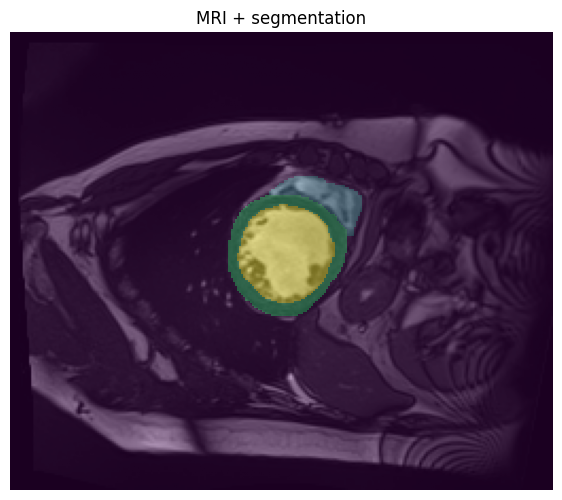

In [64]:
plt.figure(figsize=(7, 7))

plt.imshow(image[:, :, slice_id], cmap="gray")
plt.imshow(
    mask[:, :, slice_id],
    alpha=0.4,
    interpolation="nearest"
)

plt.title("MRI + segmentation")
plt.axis("off")

plt.show()

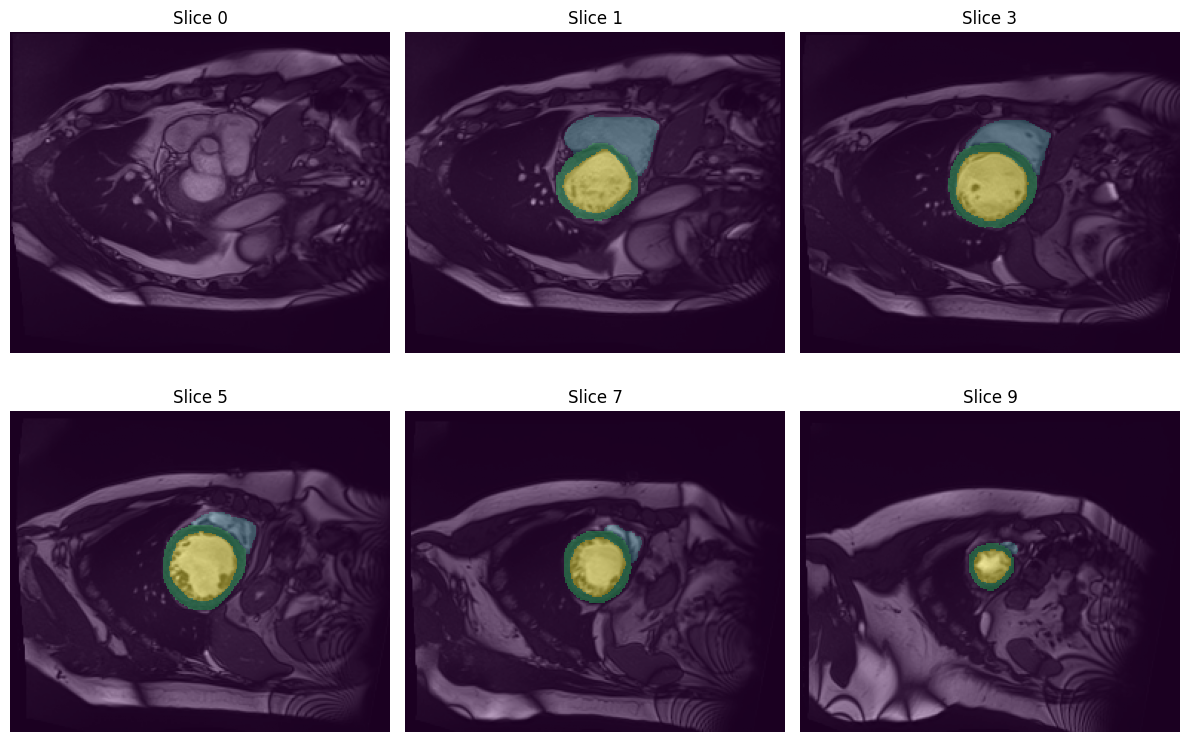

In [65]:
indices = np.linspace(
    0,
    image.shape[2] - 1,
    6
).astype(int)

fig, axes = plt.subplots(2, 3, figsize=(12, 8))

for ax, idx in zip(axes.flat, indices):

    ax.imshow(image[:, :, idx], cmap="gray")
    ax.imshow(
        mask[:, :, idx],
        alpha=0.4,
        interpolation="nearest"
    )

    ax.set_title(f"Slice {idx}")
    ax.axis("off")

plt.tight_layout()
plt.show()

Приведем к удобному виду названия файлов и создадим пары (изображение-маска)

In [66]:
def normalize_filename(path):
    name = Path(path).name

    name = name.replace(".nii.gz", "")
    name = name.replace(".nii", "")

    name = name.replace("_0000", "")

    return name

In [67]:
def make_pairs(image_dir, mask_dir):

    images = (
        list(Path(image_dir).glob("*.nii")) +
        list(Path(image_dir).glob("*.nii.gz"))
    )

    masks = (
        list(Path(mask_dir).glob("*.nii")) +
        list(Path(mask_dir).glob("*.nii.gz"))
    )

    mask_dict = {
        normalize_filename(x): x
        for x in masks
    }

    pairs = []

    for image_path in images:

        key = normalize_filename(image_path)

        if key in mask_dict:
            pairs.append(
                (image_path, mask_dict[key])
            )

    return sorted(pairs)

In [68]:
train_pairs = make_pairs(
    TRAIN_IMG_DIR,
    TRAIN_MASK_DIR
)

test_pairs = make_pairs(
    TEST_IMG_DIR,
    TEST_MASK_DIR
)

print("Train pairs:", len(train_pairs))
print("Test pairs:", len(test_pairs))

print(train_pairs[:3])

Train pairs: 224
Test pairs: 60
[(PosixPath('/content/MRI_school_zip/MRI_school_zip/train_images/cardiac_0000_0000.nii.gz'), PosixPath('/content/MRI_school_zip/MRI_school_zip/train_labels/cardiac_0000.nii.gz')), (PosixPath('/content/MRI_school_zip/MRI_school_zip/train_images/cardiac_0001_0000.nii.gz'), PosixPath('/content/MRI_school_zip/MRI_school_zip/train_labels/cardiac_0001.nii.gz')), (PosixPath('/content/MRI_school_zip/MRI_school_zip/train_images/cardiac_0002_0000.nii.gz'), PosixPath('/content/MRI_school_zip/MRI_school_zip/train_labels/cardiac_0002.nii.gz'))]


Начинаем подготавливать данные.

Создадим функцию для изменения размера изображений и нормализации значений пикселей

In [69]:
IMAGE_SIZE = (256, 256)

resize_image = Resize(
    spatial_size=IMAGE_SIZE,
    mode="bilinear"
)

resize_mask = Resize(
    spatial_size=IMAGE_SIZE,
    mode="nearest"
)

In [70]:
def normalize_image(image):

    image = image.astype(np.float32)

    # Remove extreme values
    p1 = np.percentile(image, 1)
    p99 = np.percentile(image, 99)

    image = np.clip(image, p1, p99)

    # Min-max normalization
    image = (image - image.min()) / (
        image.max() - image.min() + 1e-8
    )

    return image

## Подготовка данных к обучению (Dataset, Dataloader)

Создаем класс датасета

In [71]:
class ACDCDataset(Dataset):

    def __init__(
        self,
        pairs,
        image_size=(256, 256)
    ):

        self.samples = []

        self.image_size = image_size

        # Create list of (image, mask, slice)
        for image_path, mask_path in pairs:

            image = load_nifti(image_path)

            for slice_idx in range(image.shape[2]):

                self.samples.append(
                    (
                        image_path,
                        mask_path,
                        slice_idx
                    )
                )

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):

        image_path, mask_path, slice_idx = self.samples[idx]

        image = load_nifti(image_path)
        mask = load_nifti(mask_path)

        image = image[:, :, slice_idx]
        mask = mask[:, :, slice_idx]

        # Normalize image
        image = normalize_image(image)

        # Convert to torch tensors
        image = torch.tensor(
            image,
            dtype=torch.float32
        ).unsqueeze(0)

        mask = torch.tensor(
            mask,
            dtype=torch.long
        ).unsqueeze(0)

        # Resize
        image = torch.nn.functional.interpolate(
            image.unsqueeze(0),
            size=self.image_size,
            mode="bilinear",
            align_corners=False
        ).squeeze(0)

        mask = torch.nn.functional.interpolate(
            mask.float().unsqueeze(0),
            size=self.image_size,
            mode="nearest"
        ).squeeze(0).long()

        mask = mask.squeeze(0)

        return image, mask

Создаем объекты датасета

In [72]:
train_dataset = ACDCDataset(train_pairs)

val_dataset = ACDCDataset(test_pairs)

test_dataset = ACDCDataset(test_pairs)

print("Train slices:", len(train_dataset))
print("Validation slices:", len(val_dataset))
print("Test slices:", len(test_dataset))

Train slices: 2136
Validation slices: 690
Test slices: 690


Создаем Dataloader

In [73]:
BATCH_SIZE = 8

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

Посмотрим, какая размерность тензора, который возвращает нам Dataloader: 8 изображений, каждое содержит один канал, размер изображения 256*256.

In [74]:
images, masks = next(iter(train_loader))

print("Images:", images.shape)
print("Masks:", masks.shape)

print("Image range:", images.min().item(), images.max().item())
print("Mask classes:", torch.unique(masks))

Images: torch.Size([8, 1, 256, 256])
Masks: torch.Size([8, 256, 256])
Image range: 0.0 1.0
Mask classes: tensor([0, 1, 2, 3])


Посмотрим на сами изображения

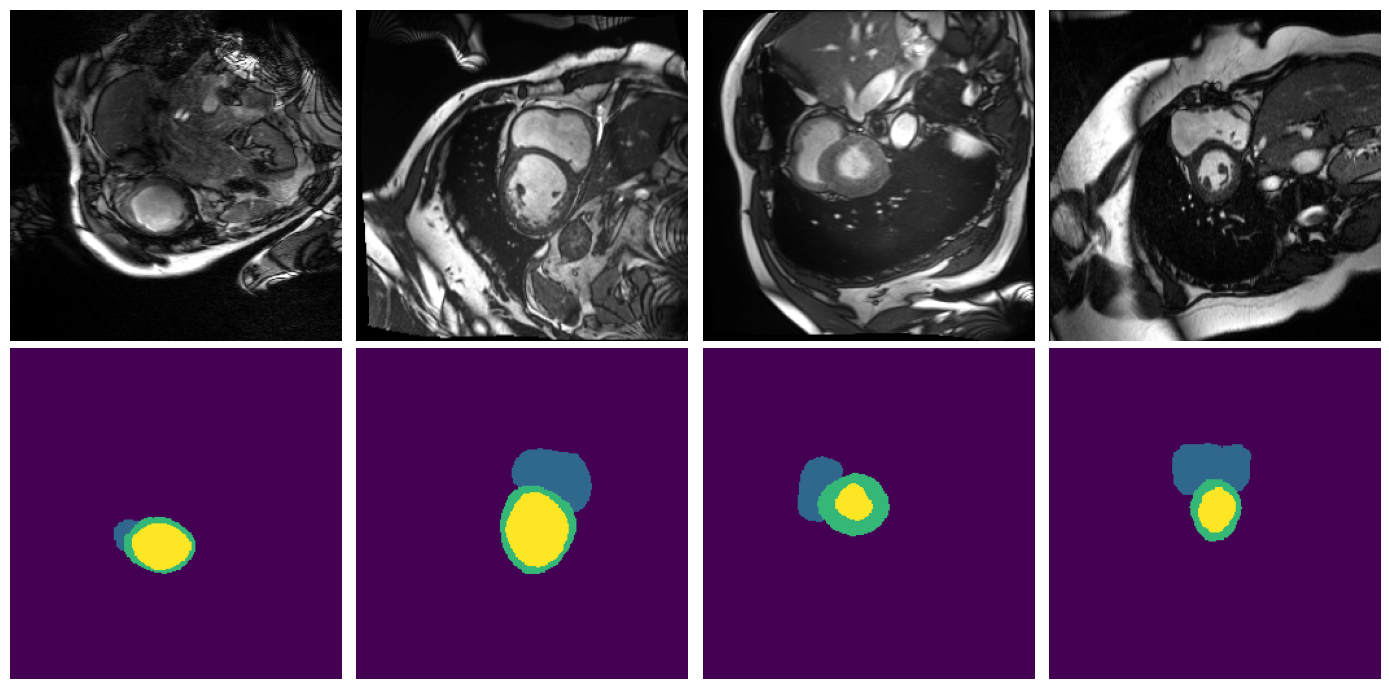

In [75]:
fig, axes = plt.subplots(
    2, 4,
    figsize=(14, 7)
)

for i in range(4):

    axes[0, i].imshow(
        images[i, 0],
        cmap="gray"
    )

    axes[0, i].axis("off")

    axes[1, i].imshow(
        masks[i]
    )

    axes[1, i].axis("off")

plt.tight_layout()
plt.show()

## Создаем модель Unet

In [76]:
class DoubleConv(nn.Module):

    def __init__(self, in_channels, out_channels):

        super().__init__()

        self.block = nn.Sequential(

            nn.Conv2d(
                in_channels,
                out_channels,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(out_channels),

            nn.ReLU(inplace=True),

            nn.Conv2d(
                out_channels,
                out_channels,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(out_channels),

            nn.ReLU(inplace=True)
        )

    def forward(self, x):

        return self.block(x)

In [77]:
class UNet(nn.Module):

    def __init__(
        self,
        in_channels=1,
        num_classes=4
    ):

        super().__init__()

        self.enc1 = DoubleConv(
            in_channels, 64
        )

        self.enc2 = DoubleConv(
            64, 128
        )

        self.enc3 = DoubleConv(
            128, 256
        )

        self.enc4 = DoubleConv(
            256, 512
        )

        self.pool = nn.MaxPool2d(2)

        self.bottleneck = DoubleConv(
            512, 1024
        )

        self.up4 = nn.ConvTranspose2d(
            1024, 512, 2, stride=2
        )

        self.dec4 = DoubleConv(
            1024, 512
        )

        self.up3 = nn.ConvTranspose2d(
            512, 256, 2, stride=2
        )

        self.dec3 = DoubleConv(
            512, 256
        )

        self.up2 = nn.ConvTranspose2d(
            256, 128, 2, stride=2
        )

        self.dec2 = DoubleConv(
            256, 128
        )

        self.up1 = nn.ConvTranspose2d(
            128, 64, 2, stride=2
        )

        self.dec1 = DoubleConv(
            128, 64
        )

        self.out = nn.Conv2d(
            64,
            num_classes,
            kernel_size=1
        )

    def forward(self, x):

        e1 = self.enc1(x)

        e2 = self.enc2(
            self.pool(e1)
        )

        e3 = self.enc3(
            self.pool(e2)
        )

        e4 = self.enc4(
            self.pool(e3)
        )

        b = self.bottleneck(
            self.pool(e4)
        )

        d4 = self.up4(b)

        d4 = torch.cat(
            [d4, e4],
            dim=1
        )

        d4 = self.dec4(d4)

        d3 = self.up3(d4)

        d3 = torch.cat(
            [d3, e3],
            dim=1
        )

        d3 = self.dec3(d3)

        d2 = self.up2(d3)

        d2 = torch.cat(
            [d2, e2],
            dim=1
        )

        d2 = self.dec2(d2)

        d1 = self.up1(d2)

        d1 = torch.cat(
            [d1, e1],
            dim=1
        )

        d1 = self.dec1(d1)

        return self.out(d1)

In [78]:
model = UNet(
    in_channels=1,
    num_classes=4
).to(device)

print(model)

UNet(
  (enc1): DoubleConv(
    (block): Sequential(
      (0): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
    )
  )
  (enc2): DoubleConv(
    (block): Sequential(
      (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
    )
  )
  (enc3): DoubleConv(
    (block): Sequential(
      (0): Conv2d(128, 256, kernel_si

Посмотрим, какое количество параметров в нашей модели

In [79]:
num_params = sum(
    p.numel()
    for p in model.parameters()
)

print(
    f"Parameters: {num_params:,}"
)

Parameters: 31,042,564


Посмотрим размерность выхода нашей модели

In [80]:
x = torch.randn(
    2, 1, 256, 256
).to(device)

with torch.no_grad():

    y = model(x)

print("Input:", x.shape)
print("Output:", y.shape)

Input: torch.Size([2, 1, 256, 256])
Output: torch.Size([2, 4, 256, 256])


## Подготовка к обучению нейронной сети

Создадим функции потерь и метрики качества

In [81]:
# Площадь пересечения (количество пикселей, где и сеть, и эталон совпали).
# |A| и |B| — общие площади (количество пикселей) первого и второго множества соответственно.
# 2 пересечения / общие площади

def dice_loss(
    logits,
    targets,
    num_classes=4,
    smooth=1e-5
):

    probs = torch.softmax(logits, dim=1)

    targets_one_hot = torch.nn.functional.one_hot(
        targets,
        num_classes=num_classes
    )

    targets_one_hot = targets_one_hot.permute(
        0, 3, 1, 2
    ).float()

    dims = (0, 2, 3)

    intersection = (
        probs * targets_one_hot
    ).sum(dims)

    denominator = (
        probs + targets_one_hot
    ).sum(dims)

    dice = (
        2 * intersection + smooth
    ) / (
        denominator + smooth
    )

    # Don't include background
    dice = dice[1:]

    return 1 - dice.mean()

In [82]:
ce_loss = nn.CrossEntropyLoss()

def combined_loss(logits, targets):

    ce = ce_loss(
        logits,
        targets
    )

    dice = dice_loss(
        logits,
        targets
    )

    return ce + dice

In [83]:
def dice_score(
    logits,
    targets,
    num_classes=4,
    smooth=1e-5
):

    predictions = torch.argmax(
        logits,
        dim=1
    )

    scores = []

    for cls in range(1, num_classes):

        pred = predictions == cls
        target = targets == cls

        intersection = (
            pred & target
        ).sum().float()

        denominator = (
            pred.sum() +
            target.sum()
        ).float()

        dice = (
            2 * intersection + smooth
        ) / (
            denominator + smooth
        )

        scores.append(dice.item())

    return np.mean(scores)

In [84]:
# IoU, Intersection over Union -- это отношение площади пересечения prediction и Ground Truth к площади их объединения.

def iou_score(
    logits,
    targets,
    num_classes=4,
    smooth=1e-5
):

    predictions = torch.argmax(
        logits,
        dim=1
    )

    scores = []

    for cls in range(1, num_classes):

        pred = predictions == cls
        target = targets == cls

        intersection = (
            pred & target
        ).sum().float()

        union = (
            pred | target
        ).sum().float()

        iou = (
            intersection + smooth
        ) / (
            union + smooth
        )

        scores.append(iou.item())

    return np.mean(scores)

Создадим optimizer и зададим скорость обучения

Adam (Adaptive Moment Estimation) — это один из самых популярных и эффективных алгоритмов оптимизации (градиентного спуска) для обучения нейронных сетей.Если обычный градиентный спуск (SGD) обновляет веса с одной фиксированной скоростью для всех параметров, то Adam подбирает индивидуальную скорость обучения (learning rate) для каждого отдельного веса, основываясь на истории его прошлых изменений.

In [85]:
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3
)

In [86]:
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    patience=3,
    factor=0.5
)

Создадим функцию для обучения одной эпохи

In [87]:
def train_one_epoch(
    model,
    loader,
    optimizer,
    device
):

    model.train()

    running_loss = 0

    progress = tqdm(
        loader,
        desc="Training"
    )

    for images, masks in progress:

        images = images.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()

        logits = model(images)

        loss = combined_loss(
            logits,
            masks
        )

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        progress.set_postfix(
            loss=loss.item()
        )

    return running_loss / len(loader)

Создадим функцию для рассчета валидационных метрик

In [88]:
@torch.no_grad()
def validate(
    model,
    loader,
    device
):

    model.eval()

    losses = []
    dice_scores = []
    iou_scores = []

    for images, masks in tqdm(
        loader,
        desc="Validation"
    ):

        images = images.to(device)
        masks = masks.to(device)

        logits = model(images)

        loss = combined_loss(
            logits,
            masks
        )

        dice = dice_score(
            logits,
            masks
        )

        iou = iou_score(
            logits,
            masks
        )

        losses.append(
            loss.item()
        )

        dice_scores.append(dice)
        iou_scores.append(iou)

    return (
        np.mean(losses),
        np.mean(dice_scores),
        np.mean(iou_scores)
    )

## Обучение модели

Напишем цикл обучения

In [91]:
NUM_EPOCHS = 9

history = {
    "train_loss": [],
    "val_loss": [],
    "val_dice": [],
    "val_iou": []
}

best_dice = 0

for epoch in range(NUM_EPOCHS):

    print(
        f"\nEpoch {epoch + 1}/{NUM_EPOCHS}"
    )

    train_loss = train_one_epoch(
        model,
        train_loader,
        optimizer,
        device
    )

    val_loss, val_dice, val_iou = validate(
        model,
        val_loader,
        device
    )

    scheduler.step(val_dice)

    history["train_loss"].append(
        train_loss
    )

    history["val_loss"].append(
        val_loss
    )

    history["val_dice"].append(
        val_dice
    )

    history["val_iou"].append(
        val_iou
    )

    print(
        f"Train loss: {train_loss:.4f}"
    )

    print(
        f"Val loss:   {val_loss:.4f}"
    )

    print(
        f"Val Dice:   {val_dice:.4f}"
    )

    print(
        f"Val IoU:    {val_iou:.4f}"
    )

    # Save best model

    if val_dice > best_dice:

        best_dice = val_dice

        torch.save(
            model.state_dict(),
            "/content/drive/MyDrive/MRI_school/best_unet.pth"
        )

        print("Best model saved!")


Epoch 1/9


Training:   0%|          | 0/267 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x788a205d58a0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
  File "/usr/lib/python3.13/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x788a205d58a0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
  File "/usr/lib/

Validation:   0%|          | 0/87 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x788a205d58a0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    Exception ignored in: self._shutdown_workers()
<function _MultiProcessingDataLoaderIter.__del__ at 0x788a205d58a0>  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers

    Traceback (most recent call last):
if w.is_alive():  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__

  File "/usr/lib/python3.13/multiprocessing/process.py", line 160, in is_alive
    self._shutdown_workers()    assert self._parent_pid == os.getpid(), 'can only test a child process'
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():

  File "/usr/lib/python3.13/multiprocessing/process.py", line 1

...

Train loss: 0.1161
Val loss:   0.1528
Val Dice:   0.8840
Val IoU:    0.8021
Best model saved!

Epoch 9/9


Training:   0%|          | 0/267 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x788a205d58a0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
  File "/usr/lib/python3.13/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x788a205d58a0>
Traceback (most recent call last):
Exception ignored in:   File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
<function _MultiProcessingDataLoaderIter.__del__ at 0x788a205d58a0>    
self._shutdown_workers()Traceback (most recent call last):

  File "/usr/local/lib/pyt

Validation:   0%|          | 0/87 [00:00<?, ?it/s]

Train loss: 0.1166
Val loss:   0.1396
Val Dice:   0.8905
Val IoU:    0.8113
Best model saved!


Посмотрим на кривую обучения

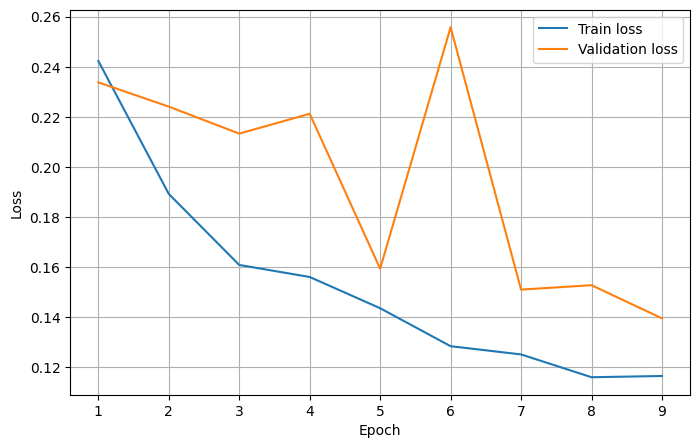

In [92]:
epochs = range(
    1,
    len(history["train_loss"]) + 1
)

plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    history["train_loss"],
    label="Train loss"
)

plt.plot(
    epochs,
    history["val_loss"],
    label="Validation loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid()

plt.show()

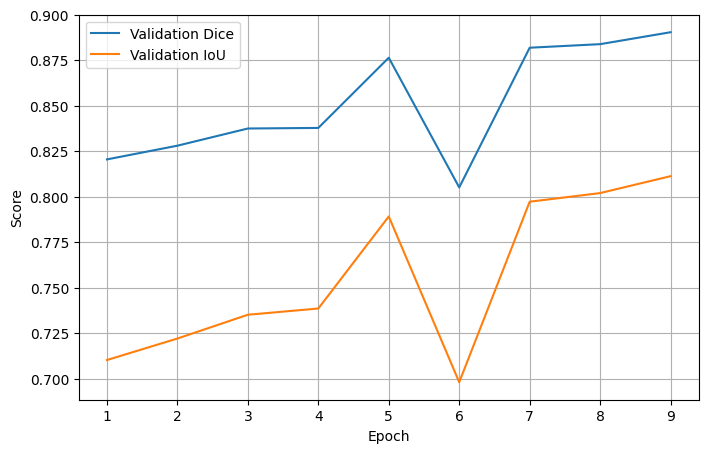

In [93]:
plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    history["val_dice"],
    label="Validation Dice"
)

plt.plot(
    epochs,
    history["val_iou"],
    label="Validation IoU"
)

plt.xlabel("Epoch")
plt.ylabel("Score")
plt.legend()
plt.grid()

plt.show()

Загрузим нашу сохраненную модель

In [94]:
model.load_state_dict(
    torch.load(
        "/content/drive/MyDrive/MRI_school/best_unet.pth",
        map_location=device
    )
)

model.eval()

UNet(
  (enc1): DoubleConv(
    (block): Sequential(
      (0): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
    )
  )
  (enc2): DoubleConv(
    (block): Sequential(
      (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
    )
  )
  (enc3): DoubleConv(
    (block): Sequential(
      (0): Conv2d(128, 256, kernel_si

Создадим функцию для предсказания

In [95]:
@torch.no_grad()
def predict(model, image):

    model.eval()

    x = image.unsqueeze(0).to(device)

    logits = model(x)

    prediction = torch.argmax(
        logits,
        dim=1
    )

    return prediction.squeeze(0).cpu()

In [96]:
image, mask = val_dataset[100]

prediction = predict(
    model,
    image
)

print("Image:", image.shape)
print("Mask:", mask.shape)
print("Prediction:", prediction.shape)

Image: torch.Size([1, 256, 256])
Mask: torch.Size([256, 256])
Prediction: torch.Size([256, 256])


## Оценка результатов сегментации

Посмотрим на получившиеся маски

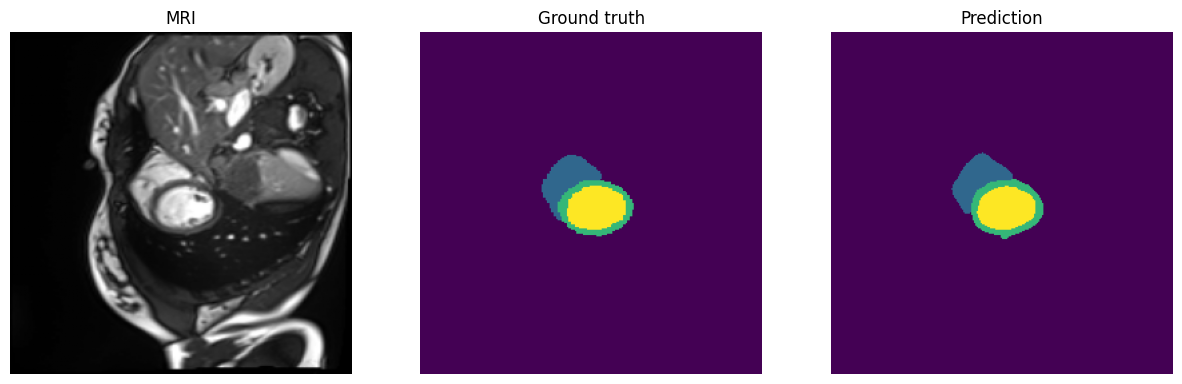

In [97]:
fig, axes = plt.subplots(
    1, 3,
    figsize=(15, 5)
)

axes[0].imshow(
    image[0],
    cmap="gray"
)

axes[0].set_title("MRI")

axes[1].imshow(
    mask
)

axes[1].set_title("Ground truth")

axes[2].imshow(
    prediction
)

axes[2].set_title("Prediction")

for ax in axes:
    ax.axis("off")

plt.show()

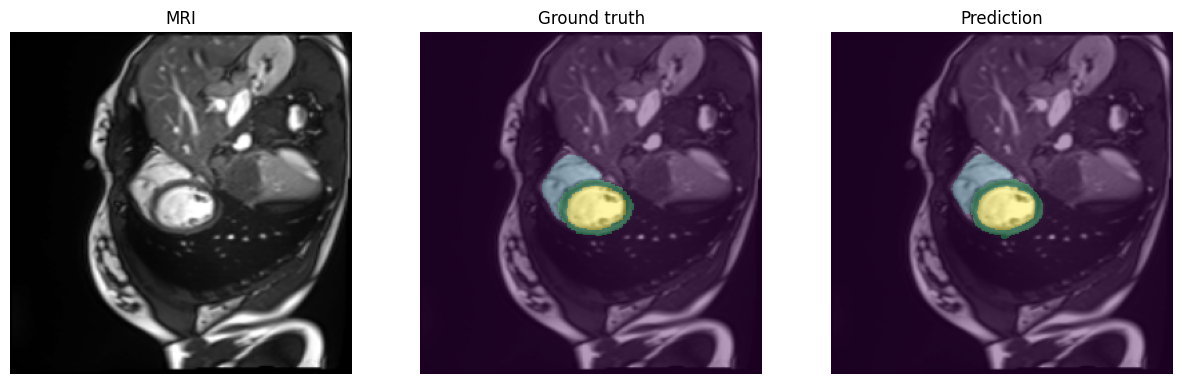

In [98]:
fig, axes = plt.subplots(
    1, 3,
    figsize=(15, 5)
)

axes[0].imshow(
    image[0],
    cmap="gray"
)

axes[0].set_title("MRI")

axes[1].imshow(
    image[0],
    cmap="gray"
)

axes[1].imshow(
    mask,
    alpha=0.4,
    interpolation="nearest"
)

axes[1].set_title("Ground truth")

axes[2].imshow(
    image[0],
    cmap="gray"
)

axes[2].imshow(
    prediction,
    alpha=0.4,
    interpolation="nearest"
)

axes[2].set_title("Prediction")

for ax in axes:
    ax.axis("off")

plt.show()

Создаим функцию для расчета метрик по отдельным классам (миокард, полость левого желудочка, полость правого желудочка)

In [99]:
def dice_from_prediction(
    prediction,
    target,
    num_classes=4
):

    scores = {}

    for cls in range(1, num_classes):

        pred = prediction == cls
        target_cls = target == cls

        intersection = (
            pred & target_cls
        ).sum().float()

        denominator = (
            pred.sum() +
            target_cls.sum()
        ).float()

        dice = (
            2 * intersection + 1e-5
        ) / (
            denominator + 1e-5
        )

        scores[cls] = dice.item()

    return scores

In [100]:
scores = dice_from_prediction(
    prediction,
    mask
)

print("RV Dice:", scores[1])
print("Myocardium Dice:", scores[2])
print("LV Dice:", scores[3])

RV Dice: 0.948650062084198
Myocardium Dice: 0.8714918494224548
LV Dice: 0.9692713022232056


In [101]:
test_loss, test_dice, test_iou = validate(
    model,
    test_loader,
    device
)

print(f"Test loss: {test_loss:.4f}")
print(f"Test Dice: {test_dice:.4f}")
print(f"Test IoU:  {test_iou:.4f}")

Validation:   0%|          | 0/87 [00:00<?, ?it/s]

Test loss: 0.1396
Test Dice: 0.8905
Test IoU:  0.8113


## Морфометрические показатели

Посмотрим, какой у нас размер пикселя

In [102]:
def get_pixel_spacing(image_path):
    """
    Returns the in-plane pixel spacing in mm.
    """

    nii = nib.load(str(image_path))

    # voxel dimensions from NIfTI header
    spacing = nii.header.get_zooms()

    pixel_spacing_x = spacing[0]
    pixel_spacing_y = spacing[1]

    return pixel_spacing_x, pixel_spacing_y


pixel_spacing = get_pixel_spacing(test_pairs[0][0])

print("Pixel spacing:", pixel_spacing, "mm")

Pixel spacing: (np.float32(1.66667), np.float32(1.66667)) mm


Посчитаем площадь сегментированных структур

In [104]:
def calculate_area(mask, class_id, pixel_spacing):
    """
    Calculate area of a segmented structure in mm².
    """

    pixel_area = pixel_spacing[0] * pixel_spacing[1]

    n_pixels = np.sum(mask == class_id)

    area = n_pixels * pixel_area

    return area

Посмотрим на примере одного среза

In [105]:
image_path, mask_path = test_pairs[0]

mask_original = load_nifti(mask_path)

slice_id = mask_original.shape[2] // 2
mask_slice = mask_original[:, :, slice_id]

pixel_spacing = get_pixel_spacing(image_path)

rv_area = calculate_area(
    mask_slice,
    class_id=1,
    pixel_spacing=pixel_spacing
)

myocardium_area = calculate_area(
    mask_slice,
    class_id=2,
    pixel_spacing=pixel_spacing
)

lv_area = calculate_area(
    mask_slice,
    class_id=3,
    pixel_spacing=pixel_spacing
)

print(f"RV area:          {rv_area:.1f} mm²")
print(f"Myocardium area:  {myocardium_area:.1f} mm²")
print(f"LV area:          {lv_area:.1f} mm²")

RV area:          2750.0 mm²
Myocardium area:  1400.0 mm²
LV area:          2588.9 mm²


Сравнить предсказанную прощадь с эталонной

In [106]:
# Возвращаем prtdiction к исходному размеру

def predict_original_size(model, image_path, slice_idx):
    """
    Predict segmentation for one slice
    and return it in the original image size.
    """

    image = load_nifti(image_path)

    slice_image = image[:, :, slice_idx]

    # Same normalization as during training
    slice_image = normalize_image(slice_image)

    x = torch.tensor(
        slice_image,
        dtype=torch.float32
    ).unsqueeze(0).unsqueeze(0)

    # Resize to model input size
    x = torch.nn.functional.interpolate(
        x,
        size=IMAGE_SIZE,
        mode="bilinear",
        align_corners=False
    )

    x = x.to(device)

    with torch.no_grad():
        logits = model(x)

        prediction = torch.argmax(
            logits,
            dim=1
        )

    prediction = prediction.float().unsqueeze(1)

    # Return to original size
    prediction = torch.nn.functional.interpolate(
        prediction,
        size=slice_image.shape,
        mode="nearest"
    )

    prediction = prediction.squeeze().cpu().numpy().astype(np.int32)

    return prediction

In [107]:
image_path, mask_path = test_pairs[0]

image_original = load_nifti(image_path)
mask_original = load_nifti(mask_path)

slice_id = image_original.shape[2] // 2

prediction_original = predict_original_size(
    model,
    image_path,
    slice_id
)

print("Original size:", mask_original[:, :, slice_id].shape)
print("Prediction size:", prediction_original.shape)

Original size: (240, 166)
Prediction size: (240, 166)


Сравниваем эталонную площадь с предсказанной

In [108]:
pixel_spacing = get_pixel_spacing(image_path)

gt_mask = mask_original[:, :, slice_id]

for class_id, name in [
    (1, "RV"),
    (2, "Myocardium"),
    (3, "LV")
]:

    gt_area = calculate_area(
        gt_mask,
        class_id,
        pixel_spacing
    )

    pred_area = calculate_area(
        prediction_original,
        class_id,
        pixel_spacing
    )

    print(
        f"{name}: "
        f"GT = {gt_area:.1f} mm², "
        f"Prediction = {pred_area:.1f} mm²"
    )

RV: GT = 2750.0 mm², Prediction = 2700.0 mm²
Myocardium: GT = 1400.0 mm², Prediction = 1602.8 mm²
LV: GT = 2588.9 mm², Prediction = 2458.3 mm²


Посмотрим визуальные результаты:

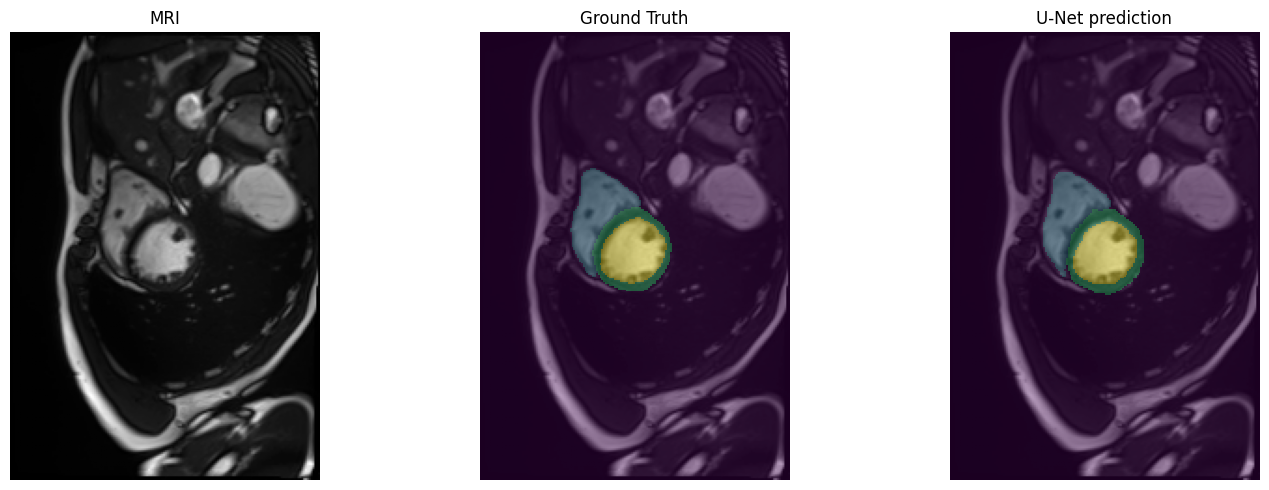

In [109]:
fig, axes = plt.subplots(
    1, 3,
    figsize=(15, 5)
)

axes[0].imshow(
    image_original[:, :, slice_id],
    cmap="gray"
)

axes[0].set_title("MRI")

axes[1].imshow(
    image_original[:, :, slice_id],
    cmap="gray"
)

axes[1].imshow(
    gt_mask,
    alpha=0.4,
    interpolation="nearest"
)

axes[1].set_title("Ground Truth")

axes[2].imshow(
    image_original[:, :, slice_id],
    cmap="gray"
)

axes[2].imshow(
    prediction_original,
    alpha=0.4,
    interpolation="nearest"
)

axes[2].set_title("U-Net prediction")

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()

Посчитаем объем левого желудочка

In [110]:
def calculate_lv_volume(
    model,
    image_path,
    mask_path=None
):
    """
    Calculate LV volume from all slices.

    If mask_path is provided, calculate volume
    from ground-truth segmentation.
    Otherwise, use U-Net prediction.
    """

    image = load_nifti(image_path)

    nii = nib.load(str(image_path))
    spacing = nii.header.get_zooms()

    pixel_spacing_x = spacing[0]
    pixel_spacing_y = spacing[1]
    slice_spacing = spacing[2]

    pixel_area = (
        pixel_spacing_x *
        pixel_spacing_y
    )

    areas = []

    if mask_path is not None:
        mask = load_nifti(mask_path)

    for slice_idx in range(image.shape[2]):

        if mask_path is not None:

            current_mask = mask[:, :, slice_idx]

        else:

            current_mask = predict_original_size(
                model,
                image_path,
                slice_idx
            )

        lv_pixels = np.sum(
            current_mask == 3
        )

        lv_area = lv_pixels * pixel_area

        areas.append(lv_area)

    areas = np.array(areas)

    volume = np.sum(areas) * slice_spacing

    # Convert mm³ to mL
    volume_ml = volume / 1000

    return volume_ml, areas

Сравним предсказанный и эталонный объем левого желудочка

In [111]:
image_path, mask_path = test_pairs[0]

gt_volume, gt_areas = calculate_lv_volume(
    model,
    image_path,
    mask_path
)

pred_volume, pred_areas = calculate_lv_volume(
    model,
    image_path
)

print(f"Ground Truth LV volume: {gt_volume:.1f} mL")
print(f"U-Net LV volume:        {pred_volume:.1f} mL")

print(
    f"Absolute error: "
    f"{abs(gt_volume - pred_volume):.1f} mL"
)

Ground Truth LV volume: 167.1 mL
U-Net LV volume:        158.0 mL
Absolute error: 9.2 mL


График площади LV по срезам

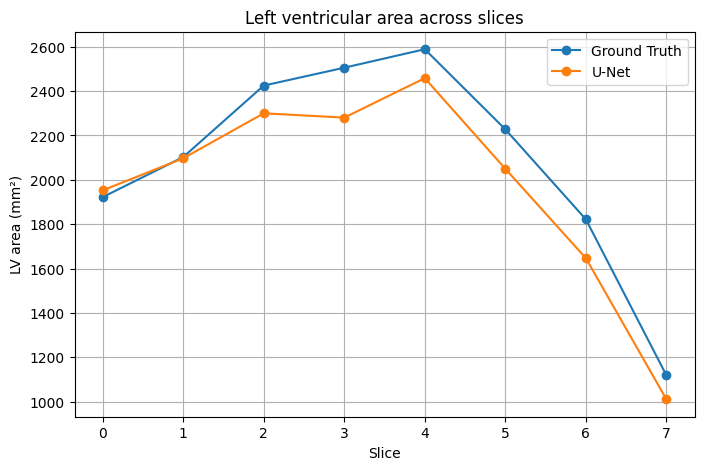

In [112]:
plt.figure(figsize=(8, 5))

slices = np.arange(len(gt_areas))

plt.plot(
    slices,
    gt_areas,
    marker="o",
    label="Ground Truth"
)

plt.plot(
    slices,
    pred_areas,
    marker="o",
    label="U-Net"
)

plt.xlabel("Slice")
plt.ylabel("LV area (mm²)")
plt.title("Left ventricular area across slices")

plt.legend()
plt.grid()

plt.show()